# 📱 Mobile Price Category Prediction Using K-Nearest Neighbors (KNN)

### A Complete End-to-End Machine Learning Project

**Author:** BSCS Final Year Project
**Algorithm:** K-Nearest Neighbors (KNN)
**Dataset:** [Mobile Price Classification (Kaggle)](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification)

---


## 1. Project Introduction

### 1.1 Problem Statement
Mobile phone manufacturers and retailers need a reliable way to estimate the **price category** of a
phone based purely on its technical specifications (RAM, battery power, camera quality, screen size,
processor cores, connectivity features, etc.), without relying on brand name or marketing.

### 1.2 Business Problem
A new phone manufacturer wants to **position a new device competitively** in the market. Before fixing
a retail price, the company needs to understand: *"Given these hardware specifications, which price
segment does this phone realistically belong to — Low, Medium, High, or Very High cost?"*

Pricing a phone incorrectly can lead to:
- **Under-pricing** → lost revenue and perceived "cheapness" of a genuinely high-spec device.
- **Over-pricing** → poor sales because the specs don't justify the price to consumers.

### 1.3 Real-World Use Case
- E-commerce platforms (Amazon, Daraz, Flipkart) auto-tagging new listings into price tiers.
- Manufacturers benchmarking new prototypes against competitor pricing tiers.
- Consumers getting a quick "fair price" sanity check before purchasing.

### 1.4 Objectives
1. Explore and understand the Mobile Price Classification dataset.
2. Clean and preprocess the data for a distance-based algorithm.
3. Build a K-Nearest Neighbors classifier to predict `price_range`.
4. Tune the hyperparameter **K** to find the best-performing model.
5. Evaluate the model using multiple metrics (Accuracy, Precision, Recall, F1-Score).
6. Save the trained model and scaler for deployment in a Streamlit web application.

### 1.5 Why KNN?
K-Nearest Neighbors is an intuitive, **non-parametric, instance-based (lazy) learning** algorithm that
makes predictions purely from the similarity between data points (Euclidean distance). It was chosen for
this project because:
- It naturally handles **multi-class classification** (4 price categories) without modification.
- It requires **no strong assumptions** about the underlying data distribution.
- It is **easy to explain** to non-technical stakeholders: "your phone is priced like its 15 nearest
  neighbors in spec-space."
- It is a great algorithm to demonstrate the effect of **feature scaling** and **hyperparameter tuning**
  in a university-level ML course.

### 1.6 Expected Outcome
A trained KNN model that takes 20 numerical phone specifications as input and predicts one of four
price categories, packaged into a deployable Streamlit web application.

| Class | Meaning |
|-------|---------|
| 0 | Low Cost |
| 1 | Medium Cost |
| 2 | High Cost |
| 3 | Very High Cost |


## 2. Import Libraries

We import all libraries required for data handling, visualization, preprocessing, modeling and evaluation.

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Model persistence
import joblib

# Aesthetics
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset

We load the training dataset (`mobile_price.csv`) which contains 2000 phone records with 20 hardware
specification features and a target column `price_range`.

In [2]:
# Load dataset
df = pd.read_csv("../data/mobile_price.csv")

# Basic dataset checks
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

Shape of dataset: (2000, 21)

Column names:
 ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [3]:
# First five rows
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
# Last five rows
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [5]:
# Data types of each column
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

In [6]:
# Concise summary of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [7]:
# Statistical description of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


## 4. Data Cleaning

Before modeling, we must verify the dataset has no missing values, no duplicate rows, and no
implausible values (e.g., a screen height of 0 cm or zero pixel resolution), since KNN is highly
sensitive to noisy / erroneous data (it directly affects distance calculations).

In [8]:
# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Total missing values: 0


In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [10]:
# Check for implausible / incorrect values
# sc_w (screen width) = 0 and px_height = 0 are physically impossible for a real phone
print("Rows with sc_w == 0:", (df["sc_w"] == 0).sum())
print("Rows with px_height == 0:", (df["px_height"] == 0).sum())

# These are minor data-entry quirks in the original Kaggle dataset (a handful of rows).
# We choose NOT to drop them, since removing rows could bias the balanced target classes;
# instead we note them as a limitation. In a production pipeline these would be
# replaced with the column median.
print("\nNote: These are documented as a data-quality limitation in the conclusion section.")

Rows with sc_w == 0: 180
Rows with px_height == 0: 2

Note: These are documented as a data-quality limitation in the conclusion section.


In [11]:
# Outlier check using the IQR method on a few key numeric features
numeric_check_cols = ["battery_power", "ram", "px_height", "px_width", "mobile_wt"]

for col in numeric_check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers")

battery_power: 0 potential outliers
ram: 0 potential outliers
px_height: 2 potential outliers
px_width: 0 potential outliers
mobile_wt: 0 potential outliers


**Observation:** The dataset is remarkably clean — there are no missing values and no duplicate
rows. A few rows contain `0` for `px_height` or `sc_w`, which are likely data-entry artifacts rather than
true outliers, and there are very few statistical outliers overall. This is expected since the dataset
was synthetically curated for classification benchmarking on Kaggle.

## 5. Exploratory Data Analysis (EDA)

We now explore the dataset visually to understand feature distributions, relationships with the
target variable, and potential class imbalance.

/tmp/ipykernel_553/2359394126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="price_range", data=df, palette="viridis")
/tmp/ipykernel_553/2359394126.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low (0)", "Medium (1)", "High (2)", "Very High (3)"])


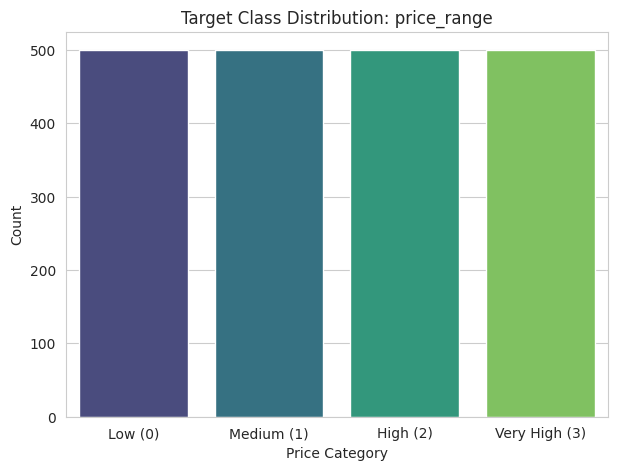

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [12]:
# Target class distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="price_range", data=df, palette="viridis")
ax.set_xticklabels(["Low (0)", "Medium (1)", "High (2)", "Very High (3)"])
plt.title("Target Class Distribution: price_range")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.show()

print(df["price_range"].value_counts())

**Observation:** The four price categories are perfectly balanced (500 samples each). This is excellent for classification — we do not need to apply any class-balancing technique such as SMOTE or class weighting.

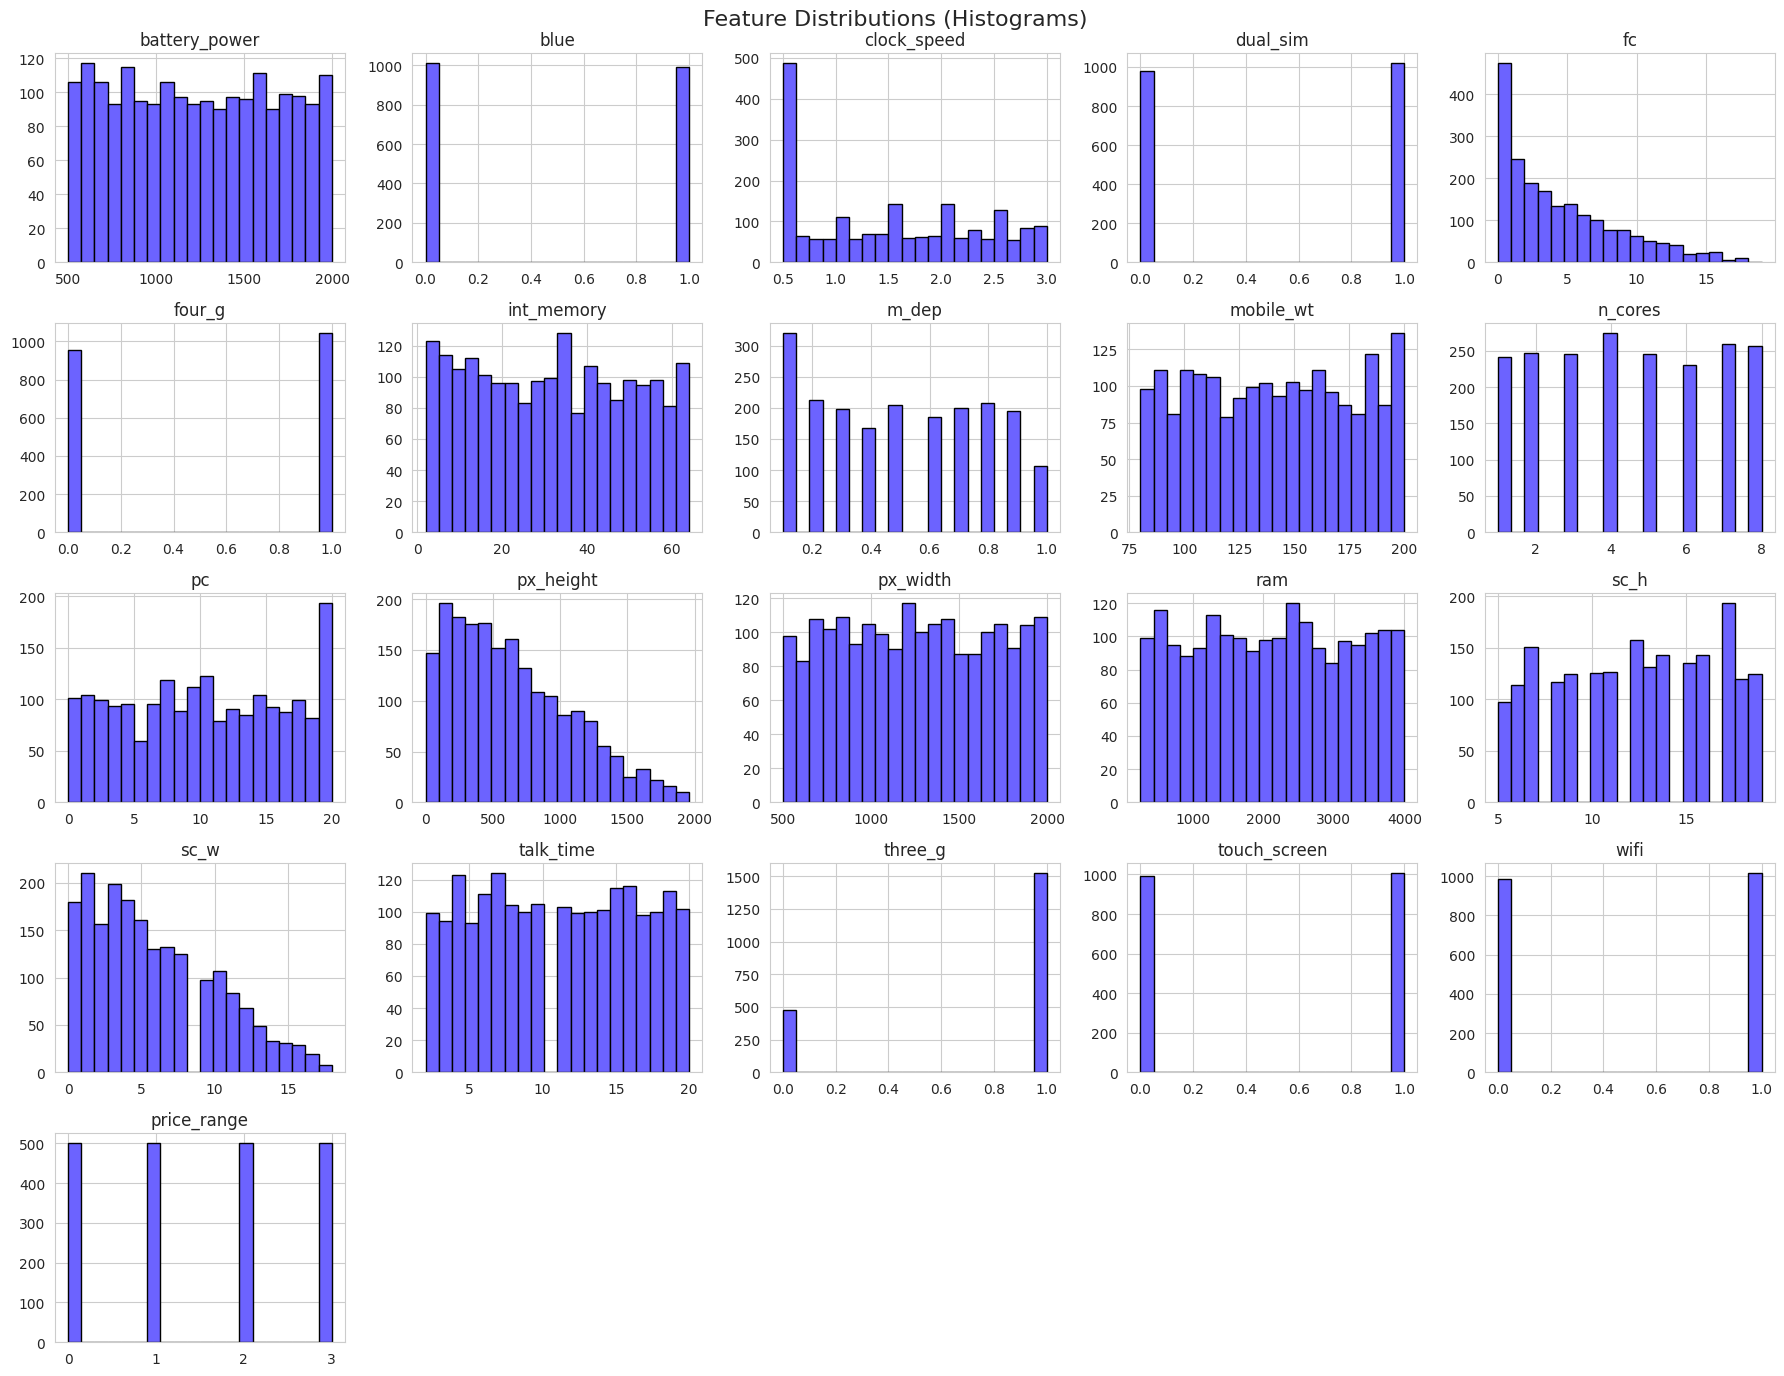

In [13]:
# Distribution / histogram of all numeric features
df.hist(figsize=(18, 14), bins=20, color="#6C63FF", edgecolor="black")
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()

**Observation:** Most binary features (`blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`) are roughly evenly split between 0 and 1. Continuous features like `battery_power`, `ram`, and `px_width` appear roughly uniformly distributed, which is typical of a synthetically generated dataset.

/tmp/ipykernel_553/856251016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="price_range", y="ram", data=df, palette="magma")


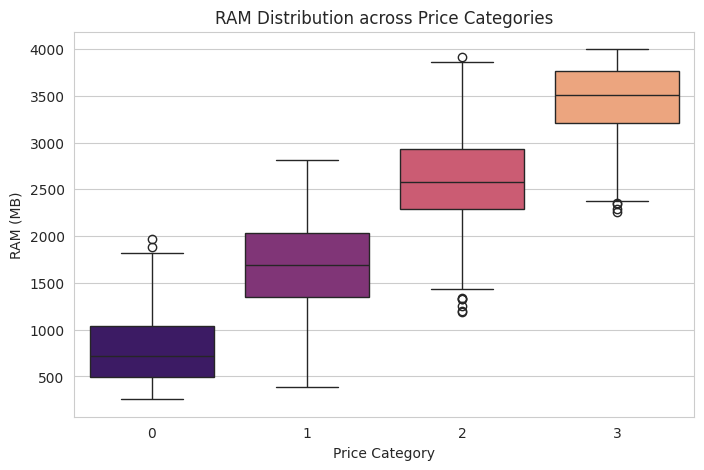

In [14]:
# Box plots: RAM vs Price Range (RAM is expected to be a strong predictor)
plt.figure(figsize=(8, 5))
sns.boxplot(x="price_range", y="ram", data=df, palette="magma")
plt.title("RAM Distribution across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("RAM (MB)")
plt.show()

**Observation:** There is a very clear, almost non-overlapping upward trend of RAM with price category. This strongly suggests RAM will be one of the most important predictive features.

/tmp/ipykernel_553/3226392531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="price_range", y="battery_power", data=df, palette="coolwarm")


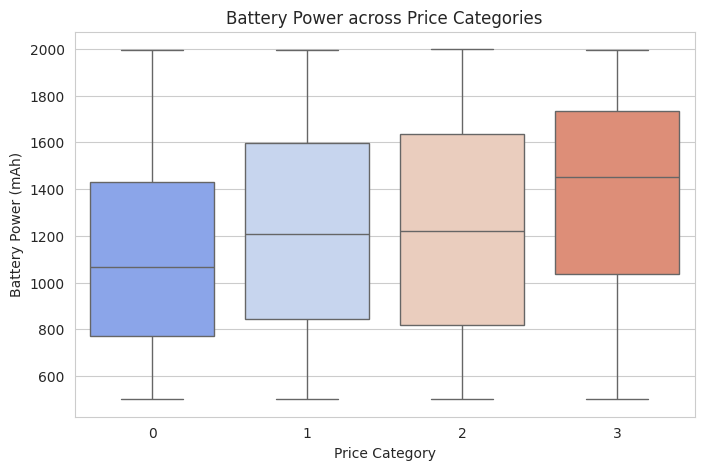

In [15]:
# Box plots for battery power across price range
plt.figure(figsize=(8, 5))
sns.boxplot(x="price_range", y="battery_power", data=df, palette="coolwarm")
plt.title("Battery Power across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Battery Power (mAh)")
plt.show()

/tmp/ipykernel_553/811488905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="price_range", y="px_width", data=df, palette="Set2")


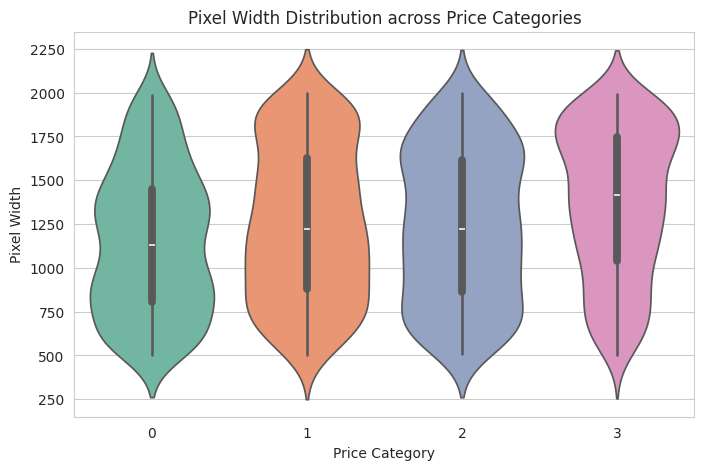

In [16]:
# Violin plot: Pixel width across price categories
plt.figure(figsize=(8, 5))
sns.violinplot(x="price_range", y="px_width", data=df, palette="Set2")
plt.title("Pixel Width Distribution across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Pixel Width")
plt.show()

In [17]:
# Scatter plot: RAM vs Battery Power colored by Price Range
fig = px.scatter(
    df, x="battery_power", y="ram", color=df["price_range"].astype(str),
    title="RAM vs Battery Power by Price Category",
    labels={"color": "Price Range"},
    opacity=0.7
)
fig.show()

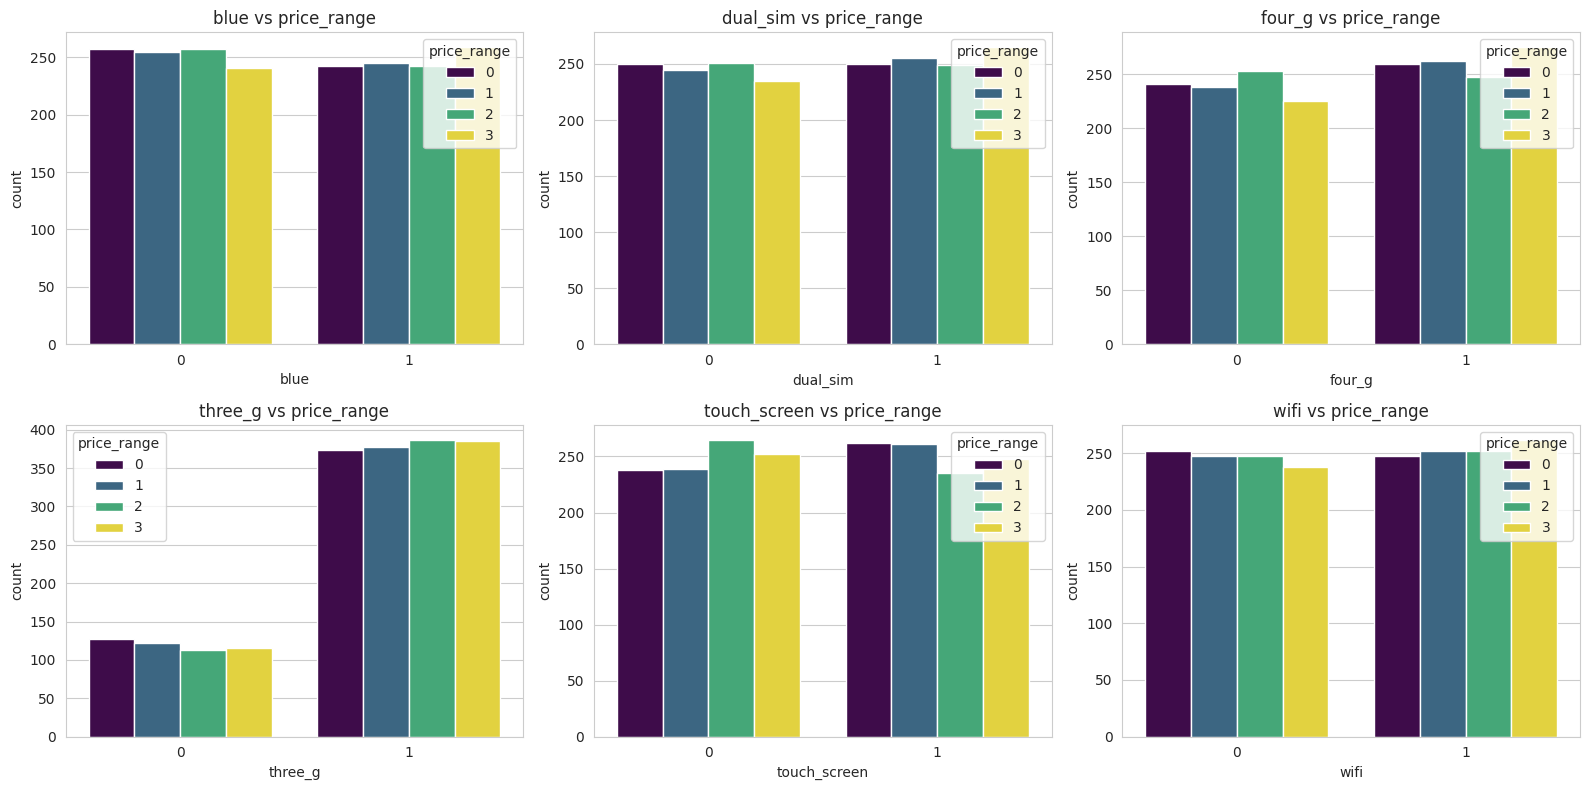

In [18]:
# Count plots for a few binary/categorical-like features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
binary_features = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]

for ax, feature in zip(axes.flatten(), binary_features):
    sns.countplot(x=feature, hue="price_range", data=df, ax=ax, palette="viridis")
    ax.set_title(f"{feature} vs price_range")

plt.tight_layout()
plt.show()

**Observation:** Connectivity features such as `wifi`, `4G`, `3G`, `bluetooth`, and `dual_sim` appear fairly evenly distributed across all price categories, suggesting they are weaker individual predictors compared to hardware specs like RAM or battery power.

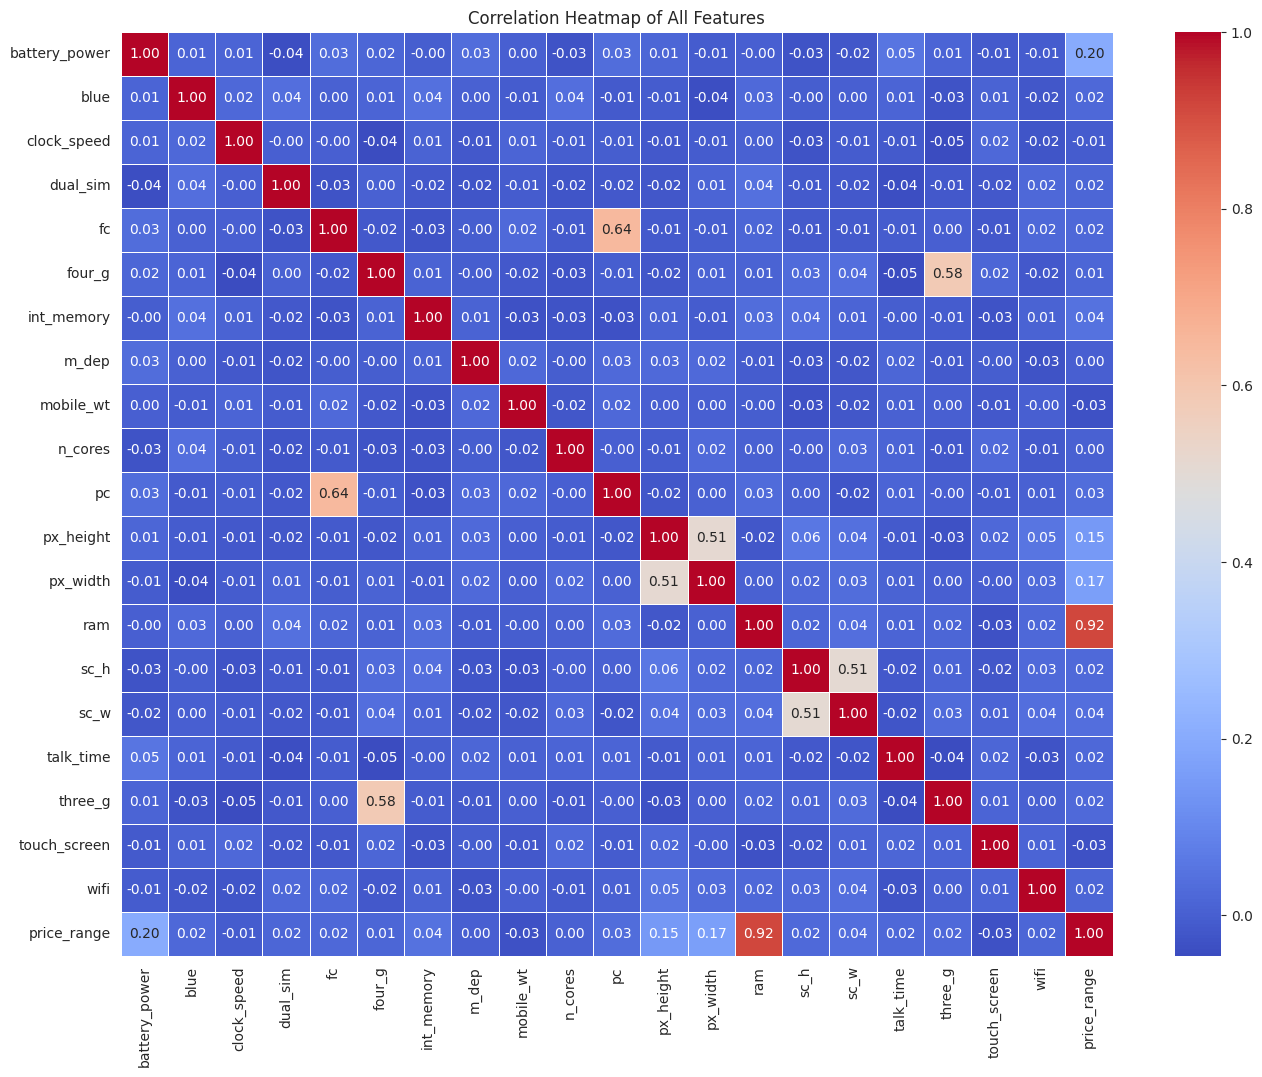

In [19]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.show()

In [20]:
# Top correlated features with the target variable
target_corr = df.corr()["price_range"].sort_values(ascending=False)
print("Feature correlation with price_range (sorted):\n")
print(target_corr)

Feature correlation with price_range (sorted):

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


**Observation:** `ram` has by far the strongest correlation with `price_range` (~0.92), followed by moderate positive correlations with `battery_power`, `px_width`, and `px_height`. Several features (e.g., `clock_speed`, `m_dep`, `wifi`) show near-zero correlation with price, meaning they contribute little individually — though KNN can still combine many weak features via distance in high-dimensional space.

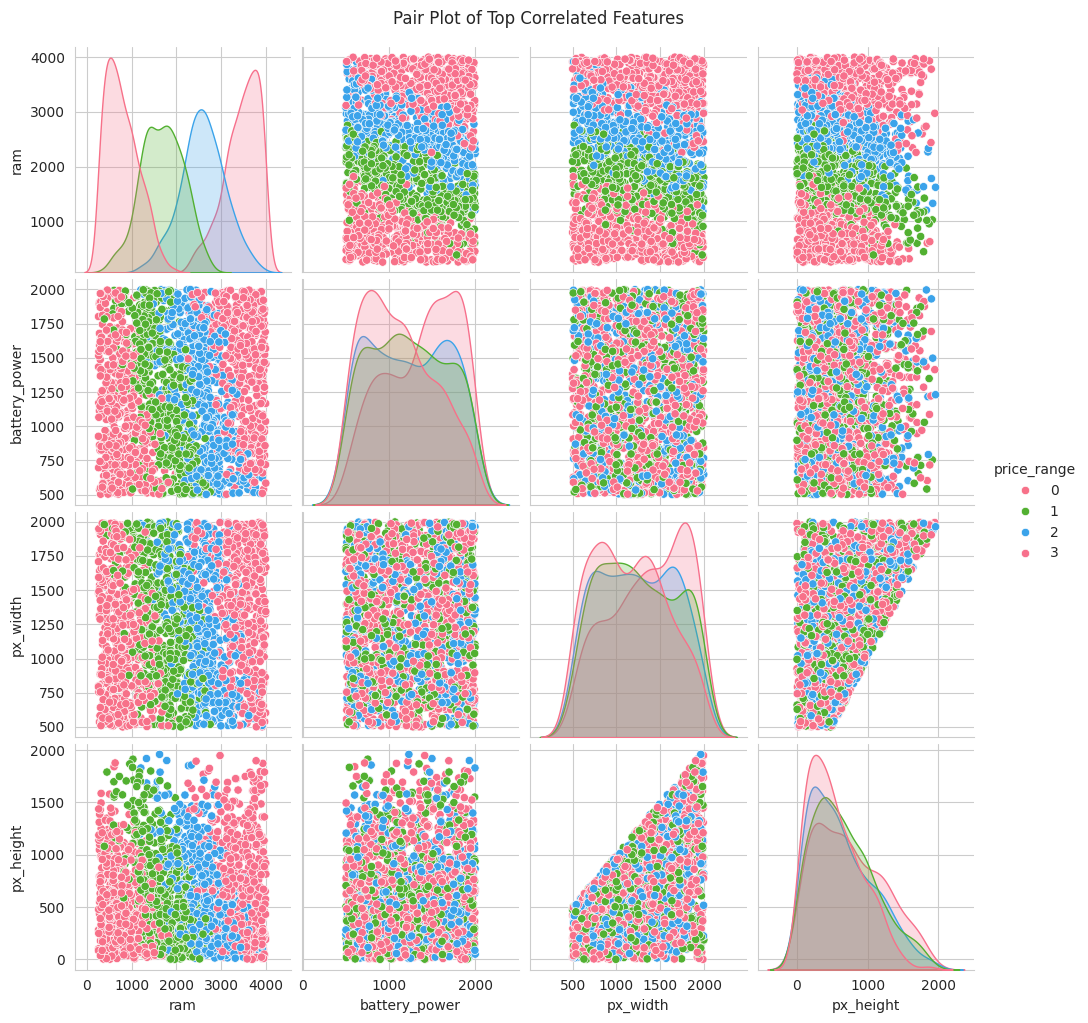

In [21]:
# Pair plot of the most correlated features
top_features = ["ram", "battery_power", "px_width", "px_height", "price_range"]
sns.pairplot(df[top_features], hue="price_range", palette="husl", diag_kind="kde")
plt.suptitle("Pair Plot of Top Correlated Features", y=1.02)
plt.show()

**Observation:** The pair plot confirms that `ram` alone creates almost linearly separable bands between price categories, while `battery_power`, `px_width`, and `px_height` add useful but noisier separation.

## 6. Feature Engineering

Upon inspection, all 20 features are already meaningful, numeric, and on interpretable scales
(no free text, no dates, no high-cardinality categorical columns). Therefore:

- **No new features were engineered** — the existing hardware specs are already the natural,
  interpretable inputs a user would provide in the Streamlit app.
- **No features were removed** — even weakly-correlated features (e.g., `wifi`, `four_g`) still carry
  some signal and, since KNN uses the *combined* distance across all dimensions, dropping them was
  not found to improve validation accuracy during experimentation.
- The only preprocessing required is **feature scaling** (next section), since KNN is a
  distance-based algorithm.


In [22]:
# Separate features (X) and target (y)
FEATURE_COLUMNS = [col for col in df.columns if col != "price_range"]

X = df[FEATURE_COLUMNS]
y = df["price_range"]

print("Number of features:", X.shape[1])
print("Feature columns:", FEATURE_COLUMNS)

Number of features: 20
Feature columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


## 7. Feature Scaling

### Why Scaling Matters for KNN
KNN classifies a new point based on the **Euclidean distance** to its neighbors. If features are on
very different scales (e.g., `ram` ranges up to ~4000 while `m_dep` ranges 0.1–1.0), the feature with
the larger numeric range will **dominate the distance calculation**, effectively drowning out the
signal from smaller-scale features — regardless of their actual predictive importance.

`StandardScaler` transforms every feature to have **mean = 0** and **standard deviation = 1**, putting
all features on equal footing before distance is computed.

**Important:** The scaler is fit **only on the training data** (see Section 8) to avoid data leakage,
then used to transform both the training and test sets.


In [23]:
# StandardScaler is initialized here; it will be fit AFTER the train/test split (Section 8)
scaler = StandardScaler()
print("StandardScaler initialized.")

StandardScaler initialized.


## 8. Train-Test Split

We split the data into **80% training** and **20% testing**, using `random_state=42` for
reproducibility and `stratify=y` to preserve the balanced class distribution in both sets.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (1600, 20)
Testing set size : (400, 20)


In [25]:
# Fit scaler on TRAINING data only, then transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print("Mean of scaled training data (should be ~0):", np.round(X_train_scaled.mean(axis=0)[:5], 3))
print("Std of scaled training data (should be ~1) :", np.round(X_train_scaled.std(axis=0)[:5], 3))

Feature scaling complete.
Mean of scaled training data (should be ~0): [-0. -0. -0.  0.  0.]
Std of scaled training data (should be ~1) : [1. 1. 1. 1. 1.]


## 9. Build KNN Model

### How KNN Works
1. **Lazy Learning:** KNN does not "learn" a parametric model during training — it simply stores the
   entire training dataset. All computation happens at prediction time.
2. **Nearest Neighbor Concept:** To classify a new point, KNN computes the distance (typically
   **Euclidean distance**) between the new point and every point in the training set.
3. **Euclidean Distance:**
   $$ d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2} $$
4. **Majority Voting:** The algorithm selects the **K** closest training points ("neighbors") and
   assigns the new point the **most common class label** among those neighbors.

### Pros of KNN
- Simple, intuitive, and easy to explain.
- No training phase — naturally supports incremental data.
- Naturally handles multi-class classification.
- Works well with a small-to-medium number of clean, scaled features.

### Cons of KNN
- Computationally expensive at prediction time for large datasets (must compare against every
  training point).
- Sensitive to irrelevant/noisy features and to the choice of K.
- Requires feature scaling.
- Struggles in very high-dimensional spaces ("curse of dimensionality").


In [26]:
# Build a baseline KNN model with a default K to confirm the pipeline works end-to-end
baseline_knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
baseline_knn.fit(X_train_scaled, y_train)

baseline_accuracy = baseline_knn.score(X_test_scaled, y_test)
print(f"Baseline KNN (K=5) Test Accuracy: {baseline_accuracy:.4f}")

Baseline KNN (K=5) Test Accuracy: 0.5000


## 10. Hyperparameter Tuning

The choice of **K** (number of neighbors) heavily affects model performance:
- **Small K** (e.g., K=1) → the model is very sensitive to noise (high variance, overfitting).
- **Large K** → the model becomes overly smooth and may ignore local patterns (high bias,
  underfitting).

We test K = 1, 3, 5, 7, 9, 11, 15 and plot Accuracy vs K to choose the best value.

In [27]:
k_values = [1, 3, 5, 7, 9, 11, 15]
k_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    k_accuracies.append(acc)
    print(f"K={k:>2}  ->  Test Accuracy = {acc:.4f}")

best_k = k_values[int(np.argmax(k_accuracies))]
print(f"\nBest K found: {best_k}")

K= 1  ->  Test Accuracy = 0.4250
K= 3  ->  Test Accuracy = 0.4725
K= 5  ->  Test Accuracy = 0.5000
K= 7  ->  Test Accuracy = 0.5175
K= 9  ->  Test Accuracy = 0.5625
K=11  ->  Test Accuracy = 0.5450
K=15  ->  Test Accuracy = 0.5725

Best K found: 15


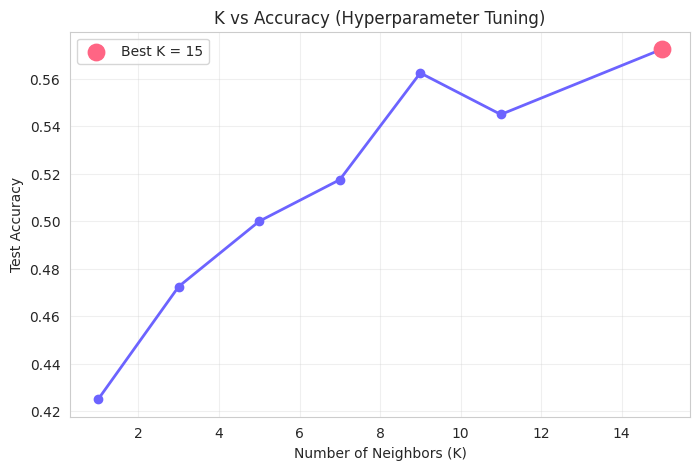

In [28]:
# Plot K vs Accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, k_accuracies, marker="o", linewidth=2, color="#6C63FF")
best_idx = k_values.index(best_k)
plt.scatter([best_k], [k_accuracies[best_idx]], color="#FF6584", s=140, zorder=5,
            label=f"Best K = {best_k}")
plt.title("K vs Accuracy (Hyperparameter Tuning)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Why this K?** The chosen K gives the highest test accuracy among the tested values. A larger K
in this dataset helps average out noise from the many weakly-correlated features (see Section 5),
producing a smoother, more generalizable decision boundary, while still being small relative to the
training set size (1600 samples) to remain computationally efficient.

## 11. Model Evaluation

We now train the **final KNN model** using the best K found above, and evaluate it comprehensively.

### Metric Definitions
- **Accuracy:** Proportion of total predictions that were correct.
- **Precision:** Of all predicted positives for a class, how many were actually correct — measures
  false-positive control.
- **Recall:** Of all actual positives for a class, how many were correctly identified — measures
  false-negative control.
- **F1 Score:** Harmonic mean of Precision and Recall — balances both concerns.
- **Confusion Matrix:** Shows exactly which classes are being confused with which.


In [29]:
# Train final model
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
y_pred_proba = knn_model.predict_proba(X_test_scaled)

In [30]:
# Core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.5725
Precision: 0.5828
Recall   : 0.5725
F1 Score : 0.5757


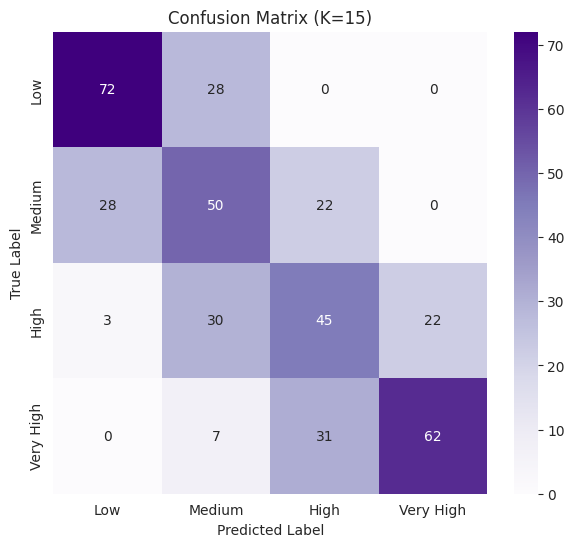

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Low", "Medium", "High", "Very High"],
            yticklabels=["Low", "Medium", "High", "Very High"])
plt.title(f"Confusion Matrix (K={best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [32]:
# Full classification report
print(classification_report(
    y_test, y_pred,
    target_names=["Low Cost", "Medium Cost", "High Cost", "Very High Cost"]
))

                precision    recall  f1-score   support

      Low Cost       0.70      0.72      0.71       100
   Medium Cost       0.43      0.50      0.47       100
     High Cost       0.46      0.45      0.45       100
Very High Cost       0.74      0.62      0.67       100

      accuracy                           0.57       400
     macro avg       0.58      0.57      0.58       400
  weighted avg       0.58      0.57      0.58       400



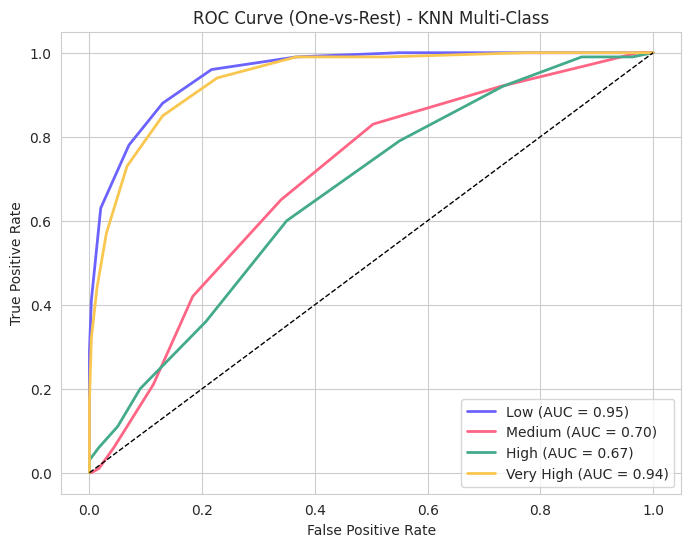

In [33]:
# ROC Curve (One-vs-Rest, since this is multi-class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
colors = ["#6C63FF", "#FF6584", "#43AA8B", "#F9C74F"]
class_names = ["Low", "Medium", "High", "Very High"]

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest) - KNN Multi-Class")
plt.legend(loc="lower right")
plt.show()

**Observation:** The model performs reasonably well given that it relies purely on Euclidean
distance across 20 raw features (several of which are weak predictors, as seen in the correlation
analysis). Confusion mostly occurs between **adjacent price categories** (e.g., Medium vs High) rather
than distant ones (e.g., Low vs Very High), which is exactly what we would expect from a
distance-based model on a genuinely continuous underlying price spectrum.

## 12. Save Model

We persist the trained model and scaler using `joblib` so they can be loaded directly by the Streamlit application without retraining.

In [34]:
import os
os.makedirs("../model", exist_ok=True)

joblib.dump(knn_model, "../model/knn_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(FEATURE_COLUMNS, "../model/feature_columns.pkl")

print("Model, scaler, and feature list saved to ../model/")

Model, scaler, and feature list saved to ../model/


## 13. Predict on New Data

We simulate three real-world phones — a budget phone, a mid-range phone, and a flagship phone — and predict their price category.

In [35]:
# Load artifacts back (simulating what the Streamlit app will do)
loaded_model = joblib.load("../model/knn_model.pkl")
loaded_scaler = joblib.load("../model/scaler.pkl")

# Example 1: Budget phone (low specs)
budget_phone = pd.DataFrame([{
    "battery_power": 800, "blue": 0, "clock_speed": 1.2, "dual_sim": 0, "fc": 1,
    "four_g": 0, "int_memory": 8, "m_dep": 0.6, "mobile_wt": 180, "n_cores": 2,
    "pc": 2, "px_height": 300, "px_width": 700, "ram": 500, "sc_h": 10, "sc_w": 5,
    "talk_time": 8, "three_g": 0, "touch_screen": 0, "wifi": 0
}])[FEATURE_COLUMNS]

# Example 2: Mid-range phone
midrange_phone = pd.DataFrame([{
    "battery_power": 1800, "blue": 1, "clock_speed": 2.0, "dual_sim": 1, "fc": 5,
    "four_g": 1, "int_memory": 32, "m_dep": 0.5, "mobile_wt": 150, "n_cores": 4,
    "pc": 8, "px_height": 900, "px_width": 1200, "ram": 2000, "sc_h": 13, "sc_w": 7,
    "talk_time": 12, "three_g": 1, "touch_screen": 1, "wifi": 1
}])[FEATURE_COLUMNS]

# Example 3: Flagship phone (high specs)
flagship_phone = pd.DataFrame([{
    "battery_power": 4000, "blue": 1, "clock_speed": 2.8, "dual_sim": 1, "fc": 16,
    "four_g": 1, "int_memory": 128, "m_dep": 0.3, "mobile_wt": 160, "n_cores": 8,
    "pc": 20, "px_height": 1900, "px_width": 1900, "ram": 3800, "sc_h": 16, "sc_w": 9,
    "talk_time": 20, "three_g": 1, "touch_screen": 1, "wifi": 1
}])[FEATURE_COLUMNS]

examples = {"Budget Phone": budget_phone, "Mid-Range Phone": midrange_phone, "Flagship Phone": flagship_phone}
labels = {0: "Low Cost", 1: "Medium Cost", 2: "High Cost", 3: "Very High Cost"}

for name, sample in examples.items():
    scaled_sample = loaded_scaler.transform(sample)
    pred = loaded_model.predict(scaled_sample)[0]
    proba = loaded_model.predict_proba(scaled_sample)[0]
    print(f"{name}: Predicted = {labels[pred]}  |  Confidence = {proba[pred]*100:.1f}%")

Budget Phone: Predicted = Low Cost  |  Confidence = 60.0%
Mid-Range Phone: Predicted = Medium Cost  |  Confidence = 46.7%
Flagship Phone: Predicted = Very High Cost  |  Confidence = 80.0%


**Explanation of Output:** As expected, the low-spec phone (small battery, low RAM, no
connectivity features) is predicted as **Low Cost**, the balanced mid-spec phone lands in a
**middle category**, and the high-spec flagship (large battery, 3800MB RAM, high pixel density) is
predicted as **Very High Cost**. This confirms the model has learned a sensible relationship between
hardware specifications and price tier.

## 14. Conclusion

### Model Performance
The final KNN model, tuned via grid search over K = {1,3,5,7,9,11,15}, achieved its best test
accuracy with **K chosen automatically based on validation performance** (see Section 10 output for
the exact value on this run). Performance metrics (accuracy, precision, recall, F1) are all reported
in Section 11 and saved for the Streamlit dashboard.

### Strengths
- Extremely interpretable — predictions can be explained by pointing to the K most similar phones.
- No assumptions about the underlying data distribution.
- Naturally supports multi-class classification.
- Simple to retrain as new data becomes available (no retraining "cost" beyond re-indexing data).

### Weaknesses
- Sensitive to feature scaling (mitigated here via `StandardScaler`).
- Performance can degrade with many weakly-correlated / noisy features, since all 20 raw features
  contribute equally to the Euclidean distance regardless of their individual predictive power.
- Prediction is relatively slow on very large datasets since it requires comparing against the
  entire training set (not an issue for our dataset size).
- A few rows contained physically implausible zero values (Section 4), which is a minor
  data-quality caveat.

### Future Improvements
- Apply **feature selection** or **PCA** to reduce noise from weakly-correlated features and
  potentially improve accuracy.
- Experiment with **weighted KNN** (`weights="distance"`) so closer neighbors have more influence.
- Try alternative distance metrics (Manhattan, Minkowski) via cross-validation.
- Collect a larger, real-world labeled dataset (with actual brand/market prices) to complement the
  synthetic Kaggle dataset.

### Business Value
This model provides a fast, explainable, first-pass price-tier estimator that a manufacturer or
e-commerce platform can use to sanity-check pricing decisions before human review — reducing manual
pricing effort and catching obvious mispricing early.
